In [1]:
import sys
sys.dont_write_bytecode = True

sys.path.insert(0, "/ubc/cs/research/beaver/projects/carlos/spatial_totalvi/model/src/")
from scvi.model._totalvi import TOTALVI

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Run spatial totalVI as development progresses 

In [2]:
import muon
import mudata as md
import scanpy as sc
import matplotlib.pyplot as plt

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [3]:
mdata = md.read_h5mu("/ubc/cs/research/beaver/projects/carlos/spatial_totalvi/data/tonsil/tonsil_pp.h5mu")
mdata

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 2492 × 2283
  2 modalities
    RNA:	2492 x 2000
      obs:	'leiden'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    Protein:	2492 x 283
      obs:	'leiden'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'

In [4]:
TOTALVI.setup_mudata(
    mdata,
    rna_layer=None,
    protein_layer=None,
    modalities ={
        "rna_layer": "RNA",
        "protein_layer": "Protein"
    }
)
model = TOTALVI(mdata)
model

INFO     Computing empirical prior initialization for protein background.                                          


TotalVI Model with the following params: 
n_latent: 20, gene_dispersion: gene, protein_dispersion: protein, gene_likelihood: nb, latent_distribution: normal
Training status: Not Trained
Model's adata is minified?: False
Model's adata is minified?: False

In [5]:
model.test

'hai'

In [6]:
model.module.gnn

SGConv(20, 20, K=1)

In [7]:
from torch_geometric.utils import subgraph
import numpy as np
import torch

# Create train/val splits
n_cells = 2492
train_size = 2467  # 2467 cells for training
train_indices = np.arange(train_size)
val_indices = np.arange(train_size, n_cells)

# Extract subgraphs
graph = torch.load("/ubc/cs/research/beaver/projects/carlos/spatial_totalvi/data/graph/graph_k5_conn.pt")
edge_index = graph["edge_index"]
edge_weight = graph["edge_weight"]

# Train subgraph
train_edge_idx, train_edge_weight = subgraph(
    torch.from_numpy(train_indices),
    edge_index,
    edge_weight,
    relabel_nodes=True
)

# Val subgraph
val_edge_idx, val_edge_weight = subgraph(
    torch.from_numpy(val_indices),
    edge_index,
    edge_weight,
    relabel_nodes=True
)

torch.save({
    'train_edge_index': train_edge_idx,
    'train_edge_weight': train_edge_weight,
    'val_edge_index': val_edge_idx,
    'val_edge_weight': val_edge_weight
}, 'train_val_subgraphs.pt')

In [8]:
train_size

2467

In [9]:
model.train(
    max_epochs=400,
    batch_size=train_size,
    external_indexing=[np.array(train_indices), np.array(val_indices)]
)

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /ubc/cs/research/beaver/projects/carlos/conda_envs/t ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /ubc/cs/research/beaver/projects/carlos/conda_envs/t ...
/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/lightning/pytorch/core/optimizer.py:317: The lr scheduler dict contains the key(s) ['

Epoch 111/400:  28%|██▊       | 111/400 [01:45<04:34,  1.05it/s, v_num=1, train_loss=1.35e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 3669.340. Signaling Trainer to stop.


In [10]:
rna = mdata.mod["RNA"]
protein = mdata.mod["Protein"]

TOTALVI_LATENT_KEY = "X_totalVI"
rna.obsm[TOTALVI_LATENT_KEY] = model.get_latent_representation()

In [11]:
rna_denoised, protein_denoised = model.get_normalized_expression(n_samples=25, return_mean=True)
rna.layers["denoised_rna"] = rna_denoised
protein.layers["denoised_protein"] = protein_denoised

protein.layers["protein_foreground_prob"] = 100 * model.get_protein_foreground_probability(
    n_samples=25, return_mean=True
)
parsed_protein_names = [p.split("_")[0] for p in protein.var_names]
protein.var["clean_names"] = parsed_protein_names
mdata.update()

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [12]:
TOTALVI_CLUSTERS_KEY = "leiden_totalVI"

sc.pp.neighbors(rna, use_rep=TOTALVI_LATENT_KEY)
sc.tl.umap(rna)
sc.tl.leiden(rna, key_added=TOTALVI_CLUSTERS_KEY)

/tmp/ipykernel_318512/3902110435.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna, key_added=TOTALVI_CLUSTERS_KEY)


In [13]:
mdata

MuData object with n_obs × n_vars = 2492 × 2283
  obs:	'_scvi_labels', '_scvi_batch'
  uns:	'_scvi_uuid', '_scvi_manager_uuid'
  2 modalities
    RNA:	2492 x 2000
      obs:	'leiden', 'leiden_totalVI'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap', 'leiden_totalVI'
      obsm:	'X_pca', 'X_umap', 'pos', 'X_totalVI'
      varm:	'PCs'
      layers:	'denoised_rna'
      obsp:	'connectivities', 'distances'
    Protein:	2492 x 283
      obs:	'leiden', '_scvi_batch'
      var:	'clean_names'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      layers:	'denoised_protein', 'protein_foreground_prob'
      obsp:	'connectivities', 'distances'

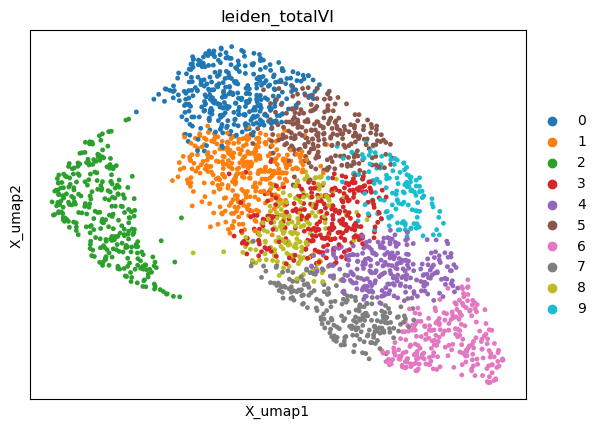

In [14]:
sc.pl.embedding(
    mdata["RNA"],
    basis="X_umap",
    color=f"{TOTALVI_CLUSTERS_KEY}",
    ncols=1,
)

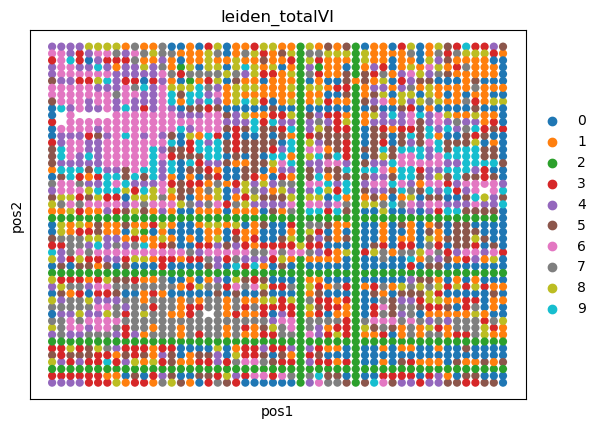

In [15]:
sc.pl.embedding(
    mdata["RNA"],
    basis="pos",
    color=f"{TOTALVI_CLUSTERS_KEY}",
    s=140,
    ncols=1,
    show=False
)
plt.gca().invert_yaxis()


In [22]:
mdata["RNA"].obsm["X_totalVI"].shape

(2492, 20)

In [ ]:
import numpy as np
np.savetxt(
    X=mdata["RNA"].obsm["X_totalVI"],
    fname="/ubc/cs/research/beaver/projects/carlos/spatial_totalvi/data/tonsil/latents_sptotalvi.tsv",
    delimiter="\t"
)

In [16]:
mdata["Protein"].var[mdata["Protein"].var["clean_names"].str.contains("CD171")]

,clean_names
CD171..LICAM..GATGGACGACAATTC,CD171..LICAM..GATGGACGACAATTC


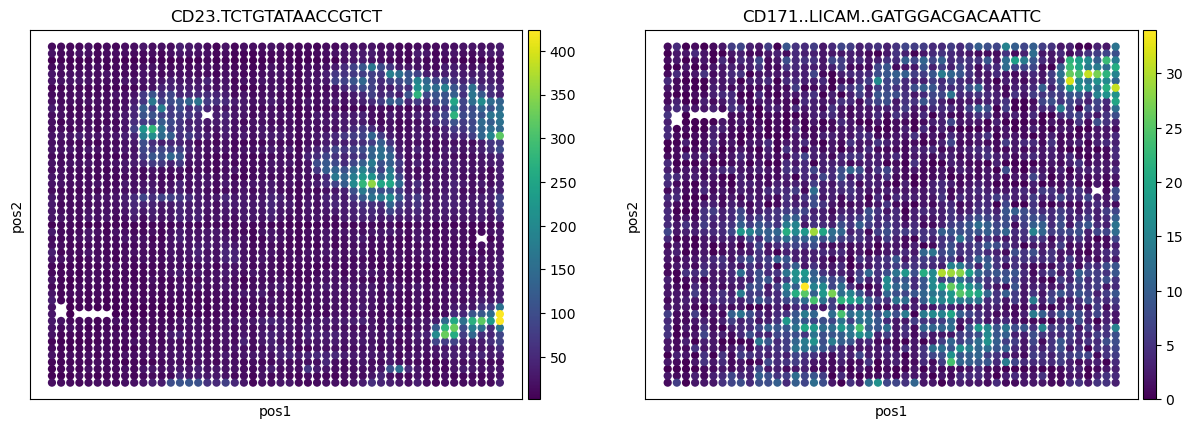

In [17]:
sc.pl.embedding(
    mdata["Protein"],
    basis="pos",
    color=["CD23.TCTGTATAACCGTCT", "CD171..LICAM..GATGGACGACAATTC"],
    s=140,
    ncols=2,
    show=False
)
plt.gca().invert_yaxis()
